# EDA — BRON crash data

This notebook explores the BRON dataset and checks whether it aligns with
the assumptions in `03_stratified_sampling.ipynb`.

**Key questions:**
1. What is the folder and file structure?
2. What are the columns in `ongevallen.txt` and what do they look like?
3. What year(s) does the data cover? (notebook 03 assumes 2018–2023)
4. Can we join crashes directly to NWB junction IDs via `JTE_ID`?
5. How many crashes are located at a junction vs. on a road segment?
6. How many Rotterdam crashes are there?
7. What does the crash-count distribution per junction look like?
   (informs where to set the low/medium/high thresholds)
8. What needs to change in notebook 03 based on this actual data structure?

## 0. Setup

In [80]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project"
BRON_DIR    = os.path.join(PROJECT_DIR, "data", "raw", "BRON")
CRS_RD      = "EPSG:28992"

print(f"BRON directory: {BRON_DIR}")

BRON directory: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\data\raw\BRON


## 1. Folder structure

Walk the BRON directory and list all files, so we know what we're working with.

In [81]:
# Walk the entire BRON directory tree and print every file found
print("BRON folder contents:")
print("=" * 60)
for root, dirs, files in os.walk(BRON_DIR):
    # Print the subfolder name relative to BRON_DIR
    rel = os.path.relpath(root, BRON_DIR)
    print(f"\n[{rel}]")
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<45} {size_kb:>8.1f} KB")

BRON folder contents:

[.]

[2020]
  Definitie.txt                                      0.5 KB

[2020\Ongevallengegevens]
  Definitie.txt                                      0.5 KB
  ongevallen.txt                                 32128.5 KB
  partijen.txt                                   19183.5 KB

[2021]
  Definitie.txt                                      0.5 KB

[2021\Ongevallengegevens]
  Definitie.txt                                      0.5 KB
  ongevallen.txt                                 35283.3 KB
  partijen.txt                                   20901.6 KB

[2022]
  Definitie.txt                                      0.5 KB

[2022\Ongevallengegevens]
  Definitie.txt                                      0.5 KB
  ongevallen.txt                                 37782.6 KB
  partijen.txt                                   22480.4 KB

[2023]
  Definitie.txt                                      0.5 KB

[2023\Ongevallengegevens]
  Definitie.txt                                      

## 2. Read the `Definitie.txt` metadata file

This file states the year range and parameters of the BRON export.
**notebook 03 assumes 2018–2023 — check if this matches.**

In [82]:
# Read the top-level metadata file describing what was requested.
# If it doesn't exist (files are organised per year with no root Definitie.txt), skip gracefully.
def_path = os.path.join(BRON_DIR, "Definitie.txt")
if os.path.exists(def_path):
    with open(def_path, encoding="latin-1") as f:
        print(f.read())
else:
    # Read from the first year subfolder instead
    year_defs = sorted(glob.glob(os.path.join(BRON_DIR, "*", "Definitie.txt")))
    if year_defs:
        print(f"No root Definitie.txt found — reading from: {os.path.relpath(year_defs[0], BRON_DIR)}")
        with open(year_defs[0], encoding="latin-1") as f:
            print(f.read())
    else:
        print("No Definitie.txt found anywhere under BRON_DIR — skipping.")

No root Definitie.txt found — reading from: 2020\Definitie.txt
Productnaam          : PGS0112-o 
Aanvraagdatum        : 24-06-2021 15:09:56 
Gebruikte Parameters : 
Begindatum                               : 01-01-2020
Einddatum                                : 31-12-2020
Zone                                     : 
Netwerk                                  : J
Doelgroep                                : 1
NWB peildatum                            : 
Kentekens                                : N
Vtgkenmerk                               : N
Alleen zwaar letsel                      : N



## 3. Load `Ongevallengegevens/ongevallen.txt`

This is the main crash table. We check its columns, data types, and a sample of rows.

In [83]:
# Find all ongevallen.txt files — one per year folder under BRON_DIR
onv_files = sorted(glob.glob(
    os.path.join(BRON_DIR, "**", "Ongevallengegevens", "ongevallen.txt"),
    recursive=True
))
print(f"Found {len(onv_files)} file(s):")
for f in onv_files:
    print(f"  {os.path.relpath(f, BRON_DIR)}")

# Load and concatenate all years — read as str first to inspect raw values.
# BRON files use latin-1 (ISO-8859-1) encoding — covers all byte values 0x00–0xFF.
parts = [pd.read_csv(f, dtype=str, encoding="latin-1") for f in onv_files]
onv = pd.concat(parts, ignore_index=True)

print(f"\nShape: {onv.shape[0]:,} rows × {onv.shape[1]} columns")
print(f"\nColumns:")
for col in onv.columns:
    n_nonempty = onv[col].notna().sum() - (onv[col] == "").sum()
    print(f"  {col:<20} {n_nonempty:>6,} non-empty")

Found 5 file(s):
  2020\Ongevallengegevens\ongevallen.txt
  2021\Ongevallengegevens\ongevallen.txt
  2022\Ongevallengegevens\ongevallen.txt
  2023\Ongevallengegevens\ongevallen.txt
  2024\Ongevallengegevens\ongevallen.txt

Shape: 600,218 rows × 66 columns

Columns:
  VKL_NUMMER           600,218 non-empty
  REGNUMMER            506,066 non-empty
  PVOPGEM                  51 non-empty
  DATUM_VKL                 0 non-empty
  DAG_CODE                  0 non-empty
  MND_NUMMER                0 non-empty
  JAAR_VKL             600,218 non-empty
  TIJDSTIP                  0 non-empty
  UUR                       0 non-empty
  DDL_ID                    0 non-empty
  AP3_CODE             600,218 non-empty
  AP4_CODE                  0 non-empty
  AP5_CODE                  0 non-empty
  ANTL_SLA                  0 non-empty
  ANTL_DOD                  0 non-empty
  ANTL_GZH                  0 non-empty
  ANTL_SEH                  0 non-empty
  ANTL_GOV                  0 non-empty
  ANTL_PTJ

In [84]:
# Inspect a few rows to get a feel for the values
onv.head(5)

,VKL_NUMMER,REGNUMMER,PVOPGEM,DATUM_VKL,DAG_CODE,MND_NUMMER,JAAR_VKL,TIJDSTIP,UUR,DDL_ID,...,PVE_NAAM,KDD_NAAM,PLT_NAAM,DIENSTCODE,DIENSTNAAM,DISTRCODE,DISTRNAAM,DAGTYPE,IND_ALC,WEEKNR
0,20200037025,2020101116,NaN,NaN,NaN,NaN,2020,NaN,NaN,NaN,...,Limburg,REGIO LIMBURG,Regionale Eenheid Limburg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20200019924,2020025999,NaN,NaN,NaN,NaN,2020,NaN,NaN,NaN,...,Limburg,REGIO LIMBURG,Regionale Eenheid Limburg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20200022792,2020077165,NaN,NaN,NaN,NaN,2020,NaN,NaN,NaN,...,Limburg,REGIO LIMBURG,Regionale Eenheid Limburg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20200016881,2020019410,NaN,NaN,NaN,NaN,2020,NaN,NaN,NaN,...,Limburg,REGIO LIMBURG,Regionale Eenheid Limburg,ZN,ZN,195,ZN District Zuid-Oost,NaN,NaN,NaN
4,20200016876,2020039331,NaN,NaN,NaN,NaN,2020,NaN,NaN,NaN,...,Limburg,REGIO LIMBURG,Regionale Eenheid Limburg,ZN,ZN,195,ZN District Zuid-Oost,NaN,NaN,NaN


## 4. Check: year coverage

notebook 03 has `BRON_YEAR_START = 2018`, `BRON_YEAR_END = 2023`.
What years are actually in this export?

In [85]:
# JAAR_VKL = year of the accident
year_col = "JAAR_VKL"
onv[year_col] = pd.to_numeric(onv[year_col], errors="coerce")

print("Year distribution:")
print(onv[year_col].value_counts().sort_index())
print(f"\nNull years: {onv[year_col].isna().sum()}")

Year distribution:
JAAR_VKL
2020    103578
2021    114219
2022    122036
2023    134005
2024    126380
Name: count, dtype: int64

Null years: 0


## 5. Check: JTE_ID format and coverage

notebook 03 plans a spatial join (buffer + sjoin). But if `JTE_ID` is already in `ongevallen.txt`,
we can do a direct tabular join instead — faster and more accurate.

Questions:
- What does the `JTE_ID` value look like? (string prefix "JTE0..." or plain integer?)
- How many accidents have a non-empty JTE_ID (junction-located)?
- How many are located on a road segment instead (JTE_ID empty, WVK_ID filled)?

In [86]:
# Check how many accidents have JTE_ID filled vs. WVK-only
has_jte = onv["JTE_ID"].notna() & (onv["JTE_ID"] != "")
has_wvk = onv["WVK_ID"].notna() & (onv["WVK_ID"] != "")

print(f"Total accidents              : {len(onv):,}")
print(f"Located at a junction (JTE)  : {has_jte.sum():,} ({has_jte.mean()*100:.1f}%)")
print(f"Located on a road segment    : {(~has_jte & has_wvk).sum():,} ({(~has_jte & has_wvk).mean()*100:.1f}%)")
print(f"Neither (missing location)   : {(~has_jte & ~has_wvk).sum():,}")

print(f"\nSample JTE_ID values (non-empty):")
print(onv.loc[has_jte, "JTE_ID"].head(10).tolist())

Total accidents              : 600,218
Located at a junction (JTE)  : 167,967 (28.0%)
Located on a road segment    : 432,251 (72.0%)
Neither (missing location)   : 0

Sample JTE_ID values (non-empty):
['367056033', '367056039', '367056010', '364053058', '368057060', '368056027', '367057019', '364051012', '369058065', '373056059']


In [87]:
# NWB JTE_IDs in our intersections file are integers (e.g. 218217037).
# BRON JTE_IDs appear as strings like "JTE0218217037".
# Check whether stripping the "JTE0" prefix yields a matching integer.

jte_sample = onv.loc[has_jte, "JTE_ID"].dropna().head(5)
print("JTE_ID → strip 'JTE0' prefix → integer:")
for val in jte_sample:
    stripped = val.lstrip("JTE0") if isinstance(val, str) else val
    print(f"  '{val}'  →  {stripped}")

print()
print("Notebook 03 note: a direct tabular join on JTE_ID is possible.")
print("The spatial buffer approach (planned in nb03) may be unnecessary for junction accidents.")

JTE_ID → strip 'JTE0' prefix → integer:
  '367056033'  →  367056033
  '367056039'  →  367056039
  '367056010'  →  367056010
  '364053058'  →  364053058
  '368057060'  →  368057060

Notebook 03 note: a direct tabular join on JTE_ID is possible.
The spatial buffer approach (planned in nb03) may be unnecessary for junction accidents.


## 6. Filter to Rotterdam and check coverage

In [88]:
# Filter to Rotterdam municipality — GME_NAAM column
rotterdam = onv[onv["GME_NAAM"].str.strip() == "Rotterdam"].copy()

print(f"All accidents             : {len(onv):,}")
print(f"Rotterdam accidents       : {len(rotterdam):,} ({len(rotterdam)/len(onv)*100:.1f}%)")
print(f"  of which at junction    : {(rotterdam['JTE_ID'].notna() & (rotterdam['JTE_ID'] != '')).sum():,}")
print(f"  of which on road segment: {(~(rotterdam['JTE_ID'].notna() & (rotterdam['JTE_ID'] != '')) & (rotterdam['WVK_ID'].notna() & (rotterdam['WVK_ID'] != ''))).sum():,}")

All accidents             : 600,218
Rotterdam accidents       : 37,539 (6.3%)
  of which at junction    : 10,478
  of which on road segment: 27,061


## 7. Load NWB intersections and check JTE_ID overlap

How many of our ~300 Rotterdam intersections appear in BRON crash data?

In [ ]:
# Load the merged NWB intersections produced by notebook 01.
# Note: geopandas restores a named index (JTE_ID) as a regular column when reading from .gpkg,
# so intersections.index is just [0, 1, 2, ...] — use intersections["JTE_ID"] for actual IDs.
intersections = gpd.read_file(
    os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
)
print(f"NWB intersections: {len(intersections):,}")
print(f"Columns: {list(intersections.columns)}")

# Confirm JTE_ID is present as a column and show sample values
if "JTE_ID" in intersections.columns:
    print(f"JTE_ID dtype  : {intersections['JTE_ID'].dtype}")
    print(f"JTE_ID sample : {intersections['JTE_ID'].head(5).tolist()}")
else:
    print("Warning: JTE_ID column not found — check the gpkg file.")

In [90]:
# Convert BRON JTE_ID strings to integers so we can match NWB junction IDs.
# JTE_ID in BRON is already a plain integer string (e.g. "218217037"), no prefix stripping needed.
def bron_jte_to_int(val):
    """Convert BRON JTE_ID value to integer. Returns NaN if empty or unparseable."""
    if pd.isna(val) or val == "":
        return np.nan
    try:
        return int(val)
    except ValueError:
        return np.nan

rotterdam["JTE_ID_int"] = rotterdam["JTE_ID"].apply(bron_jte_to_int)

# NWB junction IDs — use the JTE_ID column (not the positional index)
nwb_ids = set(intersections["JTE_ID"].astype(int))
bron_junction_ids = set(rotterdam["JTE_ID_int"].dropna().astype(int))

overlap = nwb_ids & bron_junction_ids
print(f"NWB intersections (Rotterdam)   : {len(nwb_ids):,}")
print(f"BRON junction IDs (Rotterdam)   : {len(bron_junction_ids):,}")
print(f"Intersections with ≥1 crash     : {len(overlap):,} ({len(overlap)/len(nwb_ids)*100:.1f}%)")
print(f"Intersections with 0 crashes    : {len(nwb_ids) - len(overlap):,}")

NWB intersections (Rotterdam)   : 4,858
BRON junction IDs (Rotterdam)   : 4,841
Intersections with ≥1 crash     : 1,407 (29.0%)
Intersections with 0 crashes    : 3,451


## 8. Crash-count distribution per junction

This is the key input for choosing low/medium/high thresholds in notebook 03.
We compute crash counts per NWB junction and inspect the distribution.

In [91]:
# Count crashes per junction for Rotterdam — indexed by JTE_ID integer
crash_counts = rotterdam["JTE_ID_int"].value_counts().rename("crash_count")

# Build a full series: every NWB intersection gets a crash count, 0 if not in BRON.
# Use the JTE_ID column as the index so the mapping is on actual junction IDs.
all_counts = pd.Series(0, index=intersections["JTE_ID"].astype(int), name="crash_count")
all_counts.update(crash_counts)

print("Crash count summary (per NWB junction, Rotterdam):")
print(all_counts.describe())
print(f"\nJunctions with 0 crashes : {(all_counts == 0).sum():,}")
print(f"Junctions with 1 crash   : {(all_counts == 1).sum():,}")
print(f"Junctions with 2 crashes : {(all_counts == 2).sum():,}")
print(f"Junctions with 3+ crashes: {(all_counts >= 3).sum():,}")
print(f"Junctions with 5+ crashes: {(all_counts >= 5).sum():,}")

Crash count summary (per NWB junction, Rotterdam):
count    4858.000000
mean        0.747633
std         1.893315
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        33.000000
Name: crash_count, dtype: float64

Junctions with 0 crashes : 3,451
Junctions with 1 crash   : 722
Junctions with 2 crashes : 257
Junctions with 3+ crashes: 428
Junctions with 5+ crashes: 209


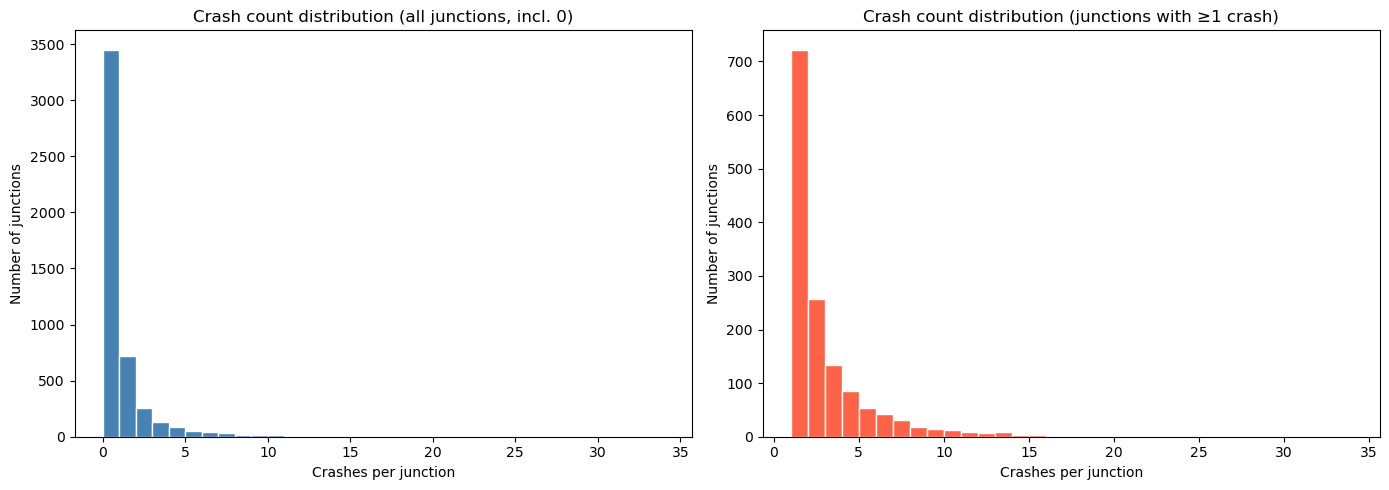


Note: 71.0% of junctions have 0 crashes in this dataset.


In [92]:
# Visualise the distribution — helps judge where to put the quantile breaks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution (including zeros)
axes[0].hist(all_counts, bins=range(0, int(all_counts.max()) + 2), edgecolor="white", color="steelblue")
axes[0].set_xlabel("Crashes per junction")
axes[0].set_ylabel("Number of junctions")
axes[0].set_title("Crash count distribution (all junctions, incl. 0)")

# Right: zoom in on the tail (junctions with ≥1 crash)
nonzero = all_counts[all_counts > 0]
if len(nonzero) == 0:
    axes[1].text(0.5, 0.5, "No junctions with ≥1 crash", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Crash count distribution (junctions with ≥1 crash)")
else:
    axes[1].hist(nonzero, bins=range(1, int(nonzero.max()) + 2), edgecolor="white", color="tomato")
    axes[1].set_xlabel("Crashes per junction")
    axes[1].set_ylabel("Number of junctions")
    axes[1].set_title("Crash count distribution (junctions with ≥1 crash)")

plt.tight_layout()
plt.show()

print(f"\nNote: {(all_counts == 0).mean()*100:.1f}% of junctions have 0 crashes in this dataset.")

## 9. Quantile break exploration

Simulate the threshold logic from notebook 03 for different quantile settings.
This helps choose `RISK_QUANTILE_BREAKS` before running notebook 03.

In [93]:
# Try several quantile split options and show the resulting class sizes.
# When many junctions have 0 crashes, quantiles can collapse to the same value,
# leaving fewer than 3 distinct bins. We detect this and adjust labels accordingly.
quantile_options = [
    [0.50, 0.80],
    [0.60, 0.85],
    [0.33, 0.67],
]

RISK_LABELS = ["laag", "midden", "hoog"]

print(f"{'Quantile breaks':<25} {'Thresholds':<22} {'Laag':>8} {'Midden':>8} {'Hoog':>8}  Note")
print("-" * 90)
for breaks in quantile_options:
    q_vals = all_counts.quantile(breaks).tolist()

    # Deduplicate edges — collapsed quantiles produce identical values
    unique_edges = sorted(set([-np.inf] + q_vals + [np.inf]))
    n_bins = len(unique_edges) - 1

    # Use only as many labels as there are bins
    labels = RISK_LABELS[:n_bins]
    note = f"⚠ quantiles collapsed → only {n_bins} bins" if n_bins < 3 else ""

    classified = pd.cut(all_counts, bins=unique_edges, labels=labels, right=True)
    counts = classified.value_counts()
    thresh_str = f"≤{q_vals[0]:.0f} / ≤{q_vals[1]:.0f}"

    print(f"{str(breaks):<25} {thresh_str:<22} {counts.get('laag', 0):>8,} {counts.get('midden', 0):>8,} {counts.get('hoog', 0):>8,}  {note}")

Quantile breaks           Thresholds                 Laag   Midden     Hoog  Note
------------------------------------------------------------------------------------------
[0.5, 0.8]                ≤0 / ≤1                   3,451      722      685  
[0.6, 0.85]               ≤0 / ≤1                   3,451      722      685  
[0.33, 0.67]              ≤0 / ≤0                   3,451    1,407        0  ⚠ quantiles collapsed → only 2 bins


## 10. Check: file format vs. notebook 03 assumptions

notebook 03 currently expects `.gpkg` or `.shp` files in `BRON_DIR`.
Print a summary of what actually needs to change.

In [94]:
# Check what file types exist in BRON_DIR (recursively)
all_files = glob.glob(os.path.join(BRON_DIR, "**", "*"), recursive=True)
extensions = pd.Series([os.path.splitext(f)[1].lower() for f in all_files if os.path.isfile(f)])
print("File extensions found in BRON_DIR:")
print(extensions.value_counts())

print()
print("=" * 60)
print("SUMMARY: What needs to change in notebook 03")
print("=" * 60)
print()
print("1. FILE FORMAT")
print("   notebook 03 expects : .gpkg / .shp in BRON_DIR")
print("   actual format       : .txt (comma-separated CSV) in subfolders")
print("   fix needed          : read 'Ongevallengegevens/ongevallen.txt' as pd.read_csv")
print()
print("2. YEAR COVERAGE")
print("   notebook 03 expects : 2018–2023 (BRON_YEAR_START / BRON_YEAR_END)")
print("   actual coverage     : see cell 4 output above")
print("   fix needed          : update year range in config to match actual data")
print()
print("3. JOIN STRATEGY")
print("   notebook 03 plans   : spatial buffer join (buffer intersections, sjoin crashes)")
print("   better approach     : direct tabular join on JTE_ID")
print("   note                : JTE_ID in BRON = 'JTE0<int>', strip prefix to get NWB integer ID")
print("   WVK-located crashes : have no JTE_ID — excluded from direct join")
print("                         (could be attributed via WVK→junction lookup, or ignored)")
print()
print("4. COLUMN NAME")
print("   notebook 03 config  : BRON_YEAR_COLUMN = 'JAAR'")
print("   actual column name  : JAAR_VKL")
print("   fix needed          : update BRON_YEAR_COLUMN = 'JAAR_VKL' in config")

File extensions found in BRON_DIR:
.txt    20
Name: count, dtype: int64

SUMMARY: What needs to change in notebook 03

1. FILE FORMAT
   notebook 03 expects : .gpkg / .shp in BRON_DIR
   actual format       : .txt (comma-separated CSV) in subfolders
   fix needed          : read 'Ongevallengegevens/ongevallen.txt' as pd.read_csv

2. YEAR COVERAGE
   notebook 03 expects : 2018–2023 (BRON_YEAR_START / BRON_YEAR_END)
   actual coverage     : see cell 4 output above
   fix needed          : update year range in config to match actual data

3. JOIN STRATEGY
   notebook 03 plans   : spatial buffer join (buffer intersections, sjoin crashes)
   better approach     : direct tabular join on JTE_ID
   note                : JTE_ID in BRON = 'JTE0<int>', strip prefix to get NWB integer ID
   WVK-located crashes : have no JTE_ID — excluded from direct join
                         (could be attributed via WVK→junction lookup, or ignored)

4. COLUMN NAME
   notebook 03 config  : BRON_YEAR_COLUMN = 'J